# Solution: Pick the Best Digit Recognizer with Cross-Validation ✍️

Compare four classifiers on the handwritten-digits data using **cross-validation**, then tune the Random Forest.

## Step 1 — Load the data

In [1]:
import pandas as pd

df = pd.read_csv('digits.csv')
print('shape:', df.shape)
df.head()

shape: (1797, 65)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## Step 2 — Features (X) and target (y)

In [2]:
X = df.drop(columns='target')   # 64 pixel columns
y = df['target']                # the digit 0-9

print('features:', X.shape[1])
print(y.value_counts().sort_index())   # roughly balanced across the 10 digits

features: 64
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


## Step 3 — Compare models with cross-validation

In [3]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = [
    LogisticRegression(max_iter=5000),
    DecisionTreeClassifier(random_state=42),
    SVC(),
    RandomForestClassifier(n_estimators=50, random_state=42),
]

for model in models:
    scores = cross_val_score(model, X, y, cv=5)
    print(f'{type(model).__name__:<24} mean cv accuracy = {scores.mean():.3f}')

LogisticRegression       mean cv accuracy = 0.914
DecisionTreeClassifier   mean cv accuracy = 0.789


SVC                      mean cv accuracy = 0.963


RandomForestClassifier   mean cv accuracy = 0.940


## Step 4 — Which model wins?

**The SVM wins**, at about **0.96**. Random Forest is close (~0.94), Logistic Regression a bit behind (~0.91), and a single Decision Tree is clearly the weakest (~0.79). SVMs tend to do very well on this kind of dense, same-scale pixel data.

## Step 5 — Tune the Random Forest

In [4]:
for n in [5, 20, 50, 100]:
    scores = cross_val_score(RandomForestClassifier(n_estimators=n, random_state=42), X, y, cv=5)
    print(f'{n:>3} trees -> cv accuracy = {scores.mean():.3f}')

  5 trees -> cv accuracy = 0.856


 20 trees -> cv accuracy = 0.932


 50 trees -> cv accuracy = 0.940


100 trees -> cv accuracy = 0.939


## Step 6 — Conclusions

1. **Ship the SVM** — it has the highest cross-validated accuracy (~0.96) on this task.
2. **Cross-validation is more reliable than one split** because it averages over 5 different test sets, so the ranking of the models doesn't hinge on one lucky (or unlucky) split.
3. The Random Forest climbs from ~0.86 (5 trees) to ~0.94 (50 trees), then **plateaus** — going to 100 trees gives no real gain, so ~50 is plenty here.

## Bonus — show a digit as an image

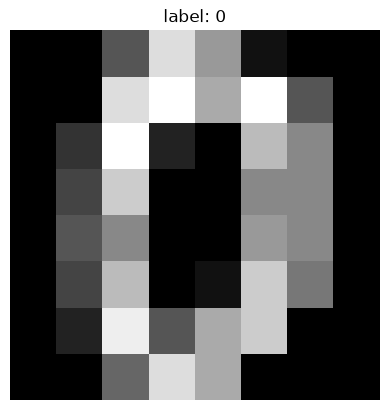

In [5]:
import matplotlib.pyplot as plt

# reshape the 64 pixels of the first row back into an 8x8 image
image = X.iloc[0].values.reshape(8, 8)
plt.imshow(image, cmap='gray')
plt.title(f'label: {y.iloc[0]}')
plt.axis('off')
plt.show()